#### Name: Ben Maxwell

# PHYS 230 Lab Assignment 9

### Monday, February 23, 2026: Chapter 5.5-5.9
- Evaluating integrals in python 
    - Gaussian Quadrature 
    - Infinite integrals
    - Multiple integrals

***Don't forget to include comments in your code and a final markdown explanation at the end of each problem.***

In [15]:
# put all import statements here
import numpy as np
from gaussxw import gaussxw
import matplotlib.pyplot as plt

## Gaussian Quadrature 1 (22 pts)

Consider the integral from last lab $$\int_{1.1}^{10.1} \frac{\sin{x}}{\ln{x}} \,dx $$ a) Re-evaulate the integral using Gaussian quadrature with 𝑁=10 points 

b) Repeat the evaluation with 2𝑁 points and evaluate the error.  

c) Compare these results with your results for both the trapezoidal and Simpson’s rules


In [ ]:
#Defing the function
def f(x):
    return np.sin(x)/np.log(x)

#Definte constants
a = 1.1
b = 10.1
N = 10

xk, wk = gaussxw(N, a, b)

#Apply guassian quadrature
s =0.0
for k in range(N):
    s += wk[k]*f(xk[k])
print(s)

2.7929415637242574


In [8]:
# part b
#Defing the function
def f(x):
    return np.sin(x)/np.log(x)

#Definte constants
a = 1.1
b = 10.1
N = 20

xk, wk = gaussxw(N, a, b)

#Apply guassian quadrature
s =0.0
for k in range(N):
    s += wk[k]*f(xk[k])
print(s)

2.84805880772841


In [11]:
# part c
def trapezoidal_int(a,b,N,f): 
    # a = lower limit of integration 
    # b = upper limit of integration 
    # N = number of steps 
    # func = function that you are integrating, should be a user-defined function 
    
    # calculate h - width of each step
    h = (b-a)/N

    #integrate using extended trapezoidal rule
    s = 0.5*f(a)+0.5*f(b)
    for k in range(1,N):
        s += f(a+k*h)
    I = h*s

    # return value of the integral 
    return(I)
def simpsons_int(a,b,N,f): 
    # a = lower limit of integration 
    # b = upper limit of integration 
    # N = number of steps 
    # func = function that you are integrating, should be a user-defined function 
    
    # calculate h - width of each step
    h = (b-a)/N

    # evaluate using simpson's rule
    s = f(a) + f(b)
    for k in range(1,N):
        if k%2 == 1: # checking for odd
            s+= 4*f(a+k*h)
        else:
            s += 2*f(a+k*h)
    I = h/3*s

    # return value of the integral 
    return(I)
print(trapezoidal_int(1.1, 10.1, 100, f))
print(simpsons_int(1.1, 10.1, 100, f))

2.9021883624907003
2.856855482008929


For part C, I "borrowed" the code that Dr. Degroot made in our notebook (Thank you). Then I call upon both functions to compare all forms at 10 points. The trapezoidal has 2.902 for 100 points, the simpson has 2.857 for 100 points, and the guassxw has 2.793 for 10 points. Most likely, the guassxw is the most accurate for so few points. 

## Gaussian Quadrature 2 (22 pts)

One of the caveats of Gaussian Quadrature is that the function being integrated must be relatively smooth. With this in mind, let’s integrate the function $$ f(x) = e^{-x^2/2}$$ from 𝑥=0 to 𝑥=1.5 using 2 sample points. 


a) First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Determine and print out the values of the sample points and weights for this problem. 
Evaluate the integral. 

c) Double the number of sample points and apply parts (b) and (c) until your error is less than our desired accuracy of $10^{−5}$


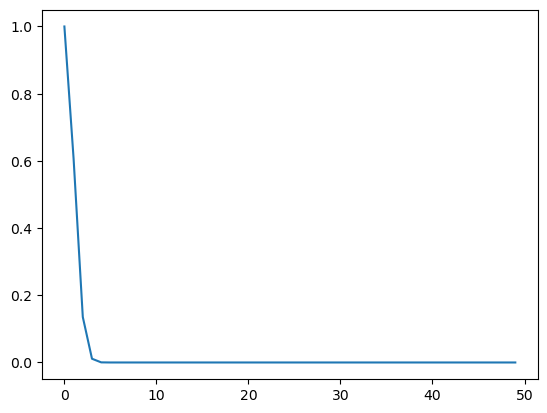

In [17]:
#Defining f(x)
def f(x):
    return np.exp(-((x**2)/2))
#Making 50 points of x
x = np.arange(0,50)
#Plotting f(x)
plt.plot(x,f(x))
plt.show()


I being my code by defining f(x) as given. Then I create a range of 50 points for x. Then I used the plt.plot function to plot x vs f(x). 
In my opinion, it doesn't look like the most smooth function ever. This probably means GQ will be less accurate. 

In [19]:
# part b
#Defing the function
def f(x):
    return np.exp(-((x**2)/2))

#Definte constants
a = 0
b = 1.5
N = 2

xk, wk = gaussxw(N, a, b)
print("The sample points are", xk, "The weights are", wk)
#Apply guassian quadrature
s =0.0
for k in range(N):
    s += wk[k]*f(xk[k])
print("The value of the integral is", s)

The sample points are [1.1830127 0.3169873] The weights are [0.75 0.75]
The value of the integral is 1.0857790801898561


To begin my code, I define f(x) as it is given. Then I make the integral goes from a=0 to b=1.5 with 2 sample points. Then, using gaussxw function with N, a, and b are defined, giving xk and wk. These are then printed. Then, the sum variale is defined as 0. A for loop is created to go through the range of N, and for all values wk[k]*f(xk[k]) are added to s. This is then printed.

In [27]:
# part c
#Defing the function
def f(x):
    return np.exp(-((x**2)/2))

#Definte constants
a = 0
b = 1.5
N = 4

xk, wk = gaussxw(N, a, b)
print("The sample points are", xk, "The weights are", wk)
#Apply guassian quadrature
s1 =0.0
for k in range(N):
    s1 += wk[k]*f(xk[k])
print("The value of the integral is", s1)

# part c

#Definte constants
a = 0
b = 1.5
N = 8

xk, wk = gaussxw(N, a, b)
print("The sample points are", xk, "The weights are", wk)
#Apply guassian quadrature
s2 =0.0
for k in range(N):
    s2 += wk[k]*f(xk[k])
print("The value of the integral is", s2)
print("The error is",abs(s2-s1))

The sample points are [1.39585223 1.00498578 0.49501422 0.10414777] The weights are [0.26089113 0.48910887 0.48910887 0.26089113]
The value of the integral is 1.0858542826593234
The sample points are [1.47021739 1.34749986 1.14414931 0.88757598 0.61242402 0.35585069
 0.15250014 0.02978261] The weights are [0.0759214  0.16678578 0.23527998 0.27201284 0.27201284 0.23527998
 0.16678578 0.0759214 ]
The value of the integral is 1.085853317666042
The error is 9.649932812827444e-07


For part c, I copied my code from part b twice, and added one line that prints the absolute value of the differences (This is how you find the error). I did this for N=4 and N=8, and it was already had an error low enough. 

## Gaussian Quadrature 3 (22 pts)

Apply the method of Gaussian Quadrature to integrate the function $$f(x) = \sin\left(\frac{1}{x}\right)$$ from $𝑥=0.01$ to $x = 2\pi$. Do so in the via the following steps: 

a)  First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Start with $N=5$ sample points & use a `while` loop to continue doubling $N$ until you achieve the accuracy you want (maybe $10^{-5}$). Comment on what happens each time you double. 


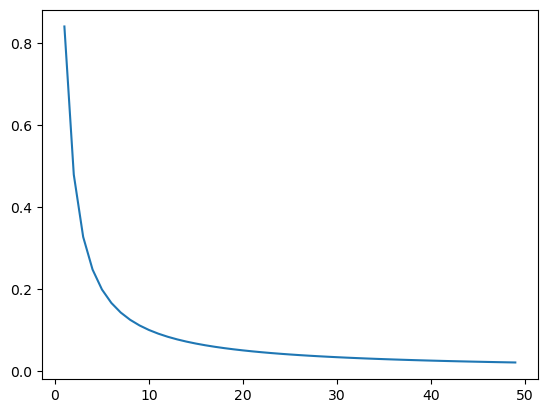

In [24]:
#Defining f(x)
def f(x):
    return np.sin(1/x)
#Making 50 points of x
x = np.arange(1,50)
#Plotting f(x)
plt.plot(x,f(x))
plt.show()

I being my code by defining f(x) as given. Then I create a range of 50 points for x. Then I used the plt.plot function to plot x vs f(x). 
The function is very smooth, and thus GQ should return an accurate value. 

In [41]:
error =10000000000
N =5
#Defing the function
def f(x):
    return np.sin(1/x)

#Definte constants
a = 0.01
b = 2*np.pi
while error>0.05:
    xk, wk = gaussxw(N, a, b)
    #Apply guassian quadrature
    s1 =0.0
    for k in range(N):
        s1 += wk[k]*f(xk[k])

    N = N *2

    xk, wk = gaussxw(N, a, b)
    #Apply guassian quadrature
    s2 =0.0
    for k in range(N):
        s2 += wk[k]*f(xk[k])
    error = abs(s2-s1)
    print(s2, error,N)

2.1795836819165104 0.3465191379178507 10
2.3948584800669477 0.21527479815043726 20
2.3031574328396247 0.09170104722732297 40
2.232173285628022 0.07098414721160262 80
2.2669528361572295 0.03477955052920745 160


I don't know what is wrong. Due to time restrictions, I have decided to move on from this problem and come back to it. 

I went back and tried to fix this. I believe it works. I define N as 5 steps. and the error as a large nymber. I use user defined function to make f. Then I define a as 0.01 and b as 2pi. Once this is completed, I use a while loop to go through the values when the error is greater than 0.05. I use the guass function to get xk ad wk. Then, I make a sum 1 as s1. I go through a range of N, and add wk[k]*f(xk[k]) to it each step. Then, I multiply N by 2 and do it all again but for s2. Once completed, I find the error which is the absolute value of s2-s1. s2, the error, and N are then all printed, and this is repeated if the erro is > 0.05. It seems the error is low enough at N=160 sample points.

## Infinite integrals (22 pts)

Let's evaluate the integral: 

$$ \int_0^\infty \frac{x^2}{\sqrt{x}}e^{-x}dx $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the variable substitution you will make for to solve this problem. This should be done in markdown using LaTex formatting. 

For this problem, 
$$  x = \frac{z}{1-z} $$ and $$ dx = \frac{dz}{(1-z)^2} $$


#### Step 2: Define the function to use in the next step for integration

In [36]:
#Defining the function that is givens
def g(z):
    #Defining the variables to change how I described above
    x = z/(1-z)
    dx = 1/(1-z)**2
    return x**2*np.exp(-x)*dx/np.sqrt(x)

I define the function as g(z), which takes a value of z and then converts it into x as it is given. It also defines dx in terms of z, and then returns the given equation. 

#### Step 3: Evaluate the integral using Gaussian Quadrature with 20 sample points

In [37]:

#Definte constants
a = 0
b = 1
N = 20

xk, wk = gaussxw(N, a, b)
#Apply guassian quadrature
s =0.0
for k in range(N):
    s += wk[k]*g(xk[k])
print("The value of the integral is", s)


The value of the integral is 1.3293510592219389


I define my constants, which is a range of a=0 to b=1. This is because of the change we did to make the 0 to inf 0 to 1 instead, making our function much easier to do. N is defined as 20 samplepoints. Then, the sum s is defined as 0. A for loop is used to add wk[k]*g(xk[k]) to s for each value of s. Then the value of the integral is printed. 

#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{3\sqrt{\pi}}{4}$

I included markdowns throughout my code. My answer was 1.32935 which is very close to the real value of 1.32934. This shows that the GQ method can still accurate find the integral of functions that go to infinity. 

## Multiple integrals (22 pts)

Let's find the mass of a metal plate that is 3 meters wide (in the $x$ direction) and 2 meters tall ($y$ direction), with a nonuniform density of (in kg/$\text{m}^2$)

$$ \sigma(x,y) = (\sin(\pi x)+1)y $$

Hint 1: the total mass is given by: $$M = \iint_R \sigma(x,y) \hspace{1mm} dA$$

*Note: don't forget to put brief comments in your code*

#### Step 1: Write the full equation for the double integral in markdown. (Hint: you'll need to swithch the cell to markdown and then you can use some of my latex coding from the cell above this)

The full equation for the double integral is
$$ I = \int_0^3 \int_0^2 (\sin(\pi x)+1)y \hspace{1mm} dy \hspace{1mm} dx $$


#### Step 2: Define the function to use in the next step for integration

In [38]:
def o(x,y):
    return((np.sin(np.pi*x)+1)*y)

This is just a function that just returns the function that is given above. 

#### Step 3: Evaluate the double integral using double Gaussian quadrature for 100 sample points along each axis. 

In [40]:
#set limites of integration and N
ax = 0
bx = 3
ay = 0
by =2
N = 100

#Calculate weights and sample points
xk, wx = gaussxw(N, ax, bx)
yk, wy = gaussxw(N, ay, by)

#Apply the sum
s= 0.
for i in range(N):
    for j in range(N):
        s += wx[i]*wy[j]*o(xk[i],yk[j])
print(s)

7.2732395447351665


I start my code defining N as 100 points, and the x limits as a=0 to b=3, and the y limits as a=0 to b=2. I then calculate xk, wx, yk, wy using gaussxw. Then I defined the sum. I then went through 2 for loops for both x and y, adding to the sum wx[i]*wy[j]*o(xk[i],yk[j]). Then I print the s. 

#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{4}{\pi}+6 \simeq 7.2732395$

I added markdowns in between explaining the process. My value is very similar to the given value, showing the accuracy of the GQ method when it comes to double integrals. 